# Time Series Analysis for Forecasting
Analyses a single Parquet time series file: stationarity, seasonality, ACF/PACF, outliers, and decomposition.

## 0 — Configuration

In [7]:
# ── Edit these lines to point at your file ────────────────────────────────────
FILE_PATH     = "../data/preprocessed/upstream_burgau_final.parquet"
TIME_COL      = "time"          # datetime column name (None if it's already the index)
VALUE_COL     = "Q_m³/s"       # value column to analyse
FREQ          = "1h"            # expected sampling frequency (pandas offset alias)
SERIES_LABEL  = "Discharge (m³/s)"

# Optional: filter to a single station (set to None to use all stations)
STATION_COL   = "station_norm"
STATION_NAME  = None            # e.g. "Arenshausen" — set to None to skip filter
# ──────────────────────────────────────────────────────────────────────────────

## 1 — Imports

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid", palette="tab10")
print("Imports OK")

Imports OK


## 2 — Load & Inspect

In [9]:
cols = [c for c in ([TIME_COL, STATION_COL, VALUE_COL] if TIME_COL else [STATION_COL, VALUE_COL]) if c]
# Read without 'columns=' first to avoid PyArrow schema mismatches with internal indices
raw = pd.read_parquet(FILE_PATH)
# Only keep requested columns that actually exist in the file
cols = [c for c in cols if c in raw.columns]
raw = raw[cols]

if STATION_NAME and STATION_COL in raw.columns:
    raw = raw[raw[STATION_COL] == STATION_NAME].copy()
    print(f"Filtered to station: {STATION_NAME!r}  ({len(raw):,} rows)")
elif STATION_COL in raw.columns:
    stations = raw[STATION_COL].unique()
    print(f"No station filter — {len(stations)} stations present: {list(stations[:10])}")

print(f"Shape  : {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Shape  : (136171, 2)
Columns: ['time', 'Q_m³/s']


,time,Q_m³/s
0,2025-06-12 09:00:00,9.42
1,2025-06-12 09:15:00,9.42
2,2025-06-12 09:30:00,9.42
3,2025-06-12 09:45:00,9.42
4,2025-06-12 10:00:00,9.42


In [10]:
# Build a clean, time-indexed series
if TIME_COL is None:
    # datetime is already the index
    df = raw[[VALUE_COL]].copy()
    df.index = pd.to_datetime(df.index, utc=True)
else:
    df = raw[[TIME_COL, VALUE_COL]].copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True)
    df = df.sort_values(TIME_COL).set_index(TIME_COL)

# Ensure UTC-aware index (parquet may already store tz info)
if df.index.tz is None:
    df.index = df.index.tz_localize("UTC")
elif str(df.index.tz) != "UTC":
    df.index = df.index.tz_convert("UTC")

# Handle duplicate timestamps (e.g. when multiple stations are present)
if df.index.has_duplicates:
    print("\nWarning: Duplicate timestamps found (multiple stations?). Averaging values per timestamp.")
    df = df.groupby(level=0).mean()

series = df[VALUE_COL]

print(f"Time range   : {series.index.min()} → {series.index.max()}")
print(f"Total rows   : {len(series):,}")
print(f"dtype        : {series.dtype}")
print(f"Inferred freq: {pd.infer_freq(series.index)}")


Time range   : 2025-06-12 09:00:00+00:00 → 2026-01-01 00:00:00+00:00
Total rows   : 19,453
dtype        : float64
Inferred freq: 15min


## 3 — Basic Statistics

In [11]:
desc = series.describe(percentiles=[.05, .25, .5, .75, .95])
print(desc.to_string())
print(f"\nSkewness : {series.skew():.3f}")
print(f"Kurtosis : {series.kurtosis():.3f}")

count    19453.000000
mean         3.674020
std          1.785668
min          1.997571
5%           2.168000
25%          2.582429
50%          3.163714
75%          4.206286
95%          7.091714
max         14.563857

Skewness : 2.633
Kurtosis : 8.644


## 4 — Missing Values & Coverage

In [12]:
expected = pd.date_range(series.index.min(), series.index.max(), freq=FREQ, tz="UTC")
n_missing_ts = len(expected) - len(series)
n_nan        = series.isna().sum()

print(f"Expected timestamps : {len(expected):,}")
print(f"Missing timestamps  : {n_missing_ts:,}  ({100*n_missing_ts/len(expected):.2f} %)")
print(f"NaN values          : {n_nan:,}  ({100*n_nan/len(series):.2f} %)")

# Reindex to full grid to expose gaps
full = series.reindex(expected)
gap_mask = full.isna()

# Find consecutive gap runs
gap_runs = []
in_gap, start = False, None
for t, v in zip(full.index, gap_mask):
    if v and not in_gap:
        in_gap, start = True, t
    elif not v and in_gap:
        gap_runs.append((start, t, (t - start).total_seconds() / 3600))
        in_gap = False
if in_gap:
    gap_runs.append((start, full.index[-1], (full.index[-1]-start).total_seconds()/3600))

if gap_runs:
    gaps_df = pd.DataFrame(gap_runs, columns=["start", "end", "duration_h"])
    print(f"\nTop-10 gaps by duration:")
    print(gaps_df.nlargest(10, "duration_h").to_string(index=False))
else:
    print("\nNo gaps detected — continuous series.")

Expected timestamps : 4,864
Missing timestamps  : -14,589  (-299.94 %)
NaN values          : 0  (0.00 %)

No gaps detected — continuous series.


## 5 — Full Time Series Plot

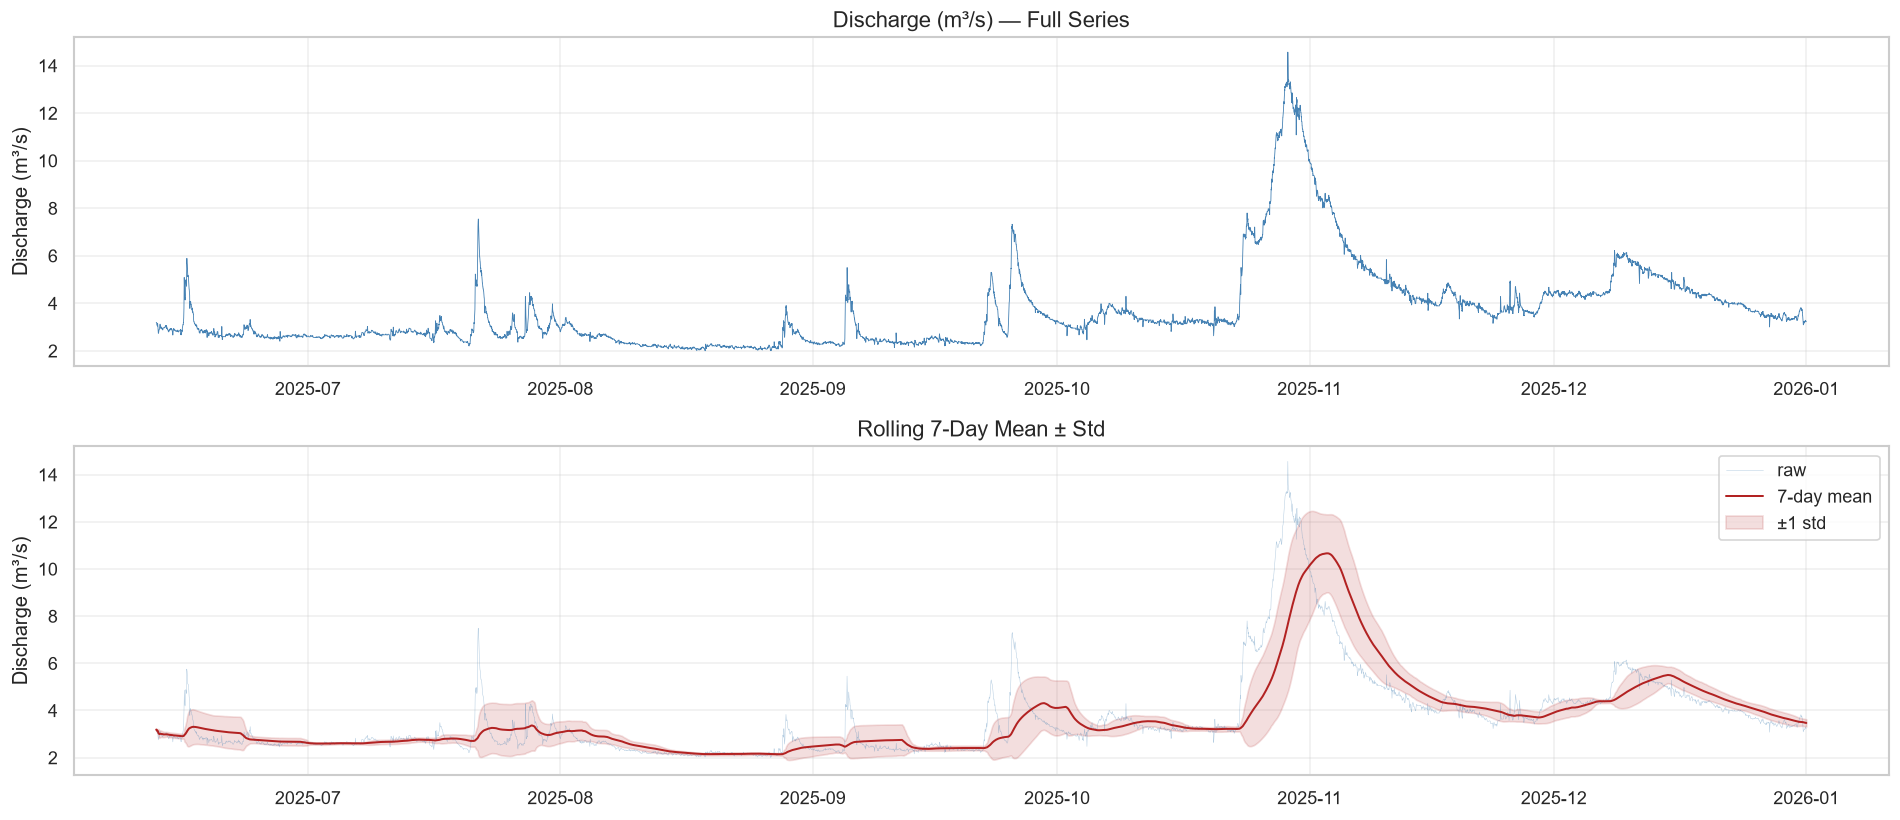

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

# Top: raw series
axes[0].plot(series.index, series.values, lw=0.5, color="steelblue")
axes[0].set_title(f"{SERIES_LABEL} — Full Series", fontsize=13)
axes[0].set_ylabel(SERIES_LABEL)

# Bottom: 7-day rolling mean + std band
roll_mean = full.rolling("7D").mean()
roll_std  = full.rolling("7D").std()
axes[1].plot(full.index, full.values, lw=0.3, alpha=0.4, color="steelblue", label="raw")
axes[1].plot(roll_mean.index, roll_mean.values, lw=1.2, color="firebrick", label="7-day mean")
axes[1].fill_between(roll_mean.index,
                      roll_mean - roll_std,
                      roll_mean + roll_std,
                      alpha=0.15, color="firebrick", label="±1 std")
axes[1].set_title("Rolling 7-Day Mean ± Std", fontsize=13)
axes[1].set_ylabel(SERIES_LABEL)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6 — Distribution

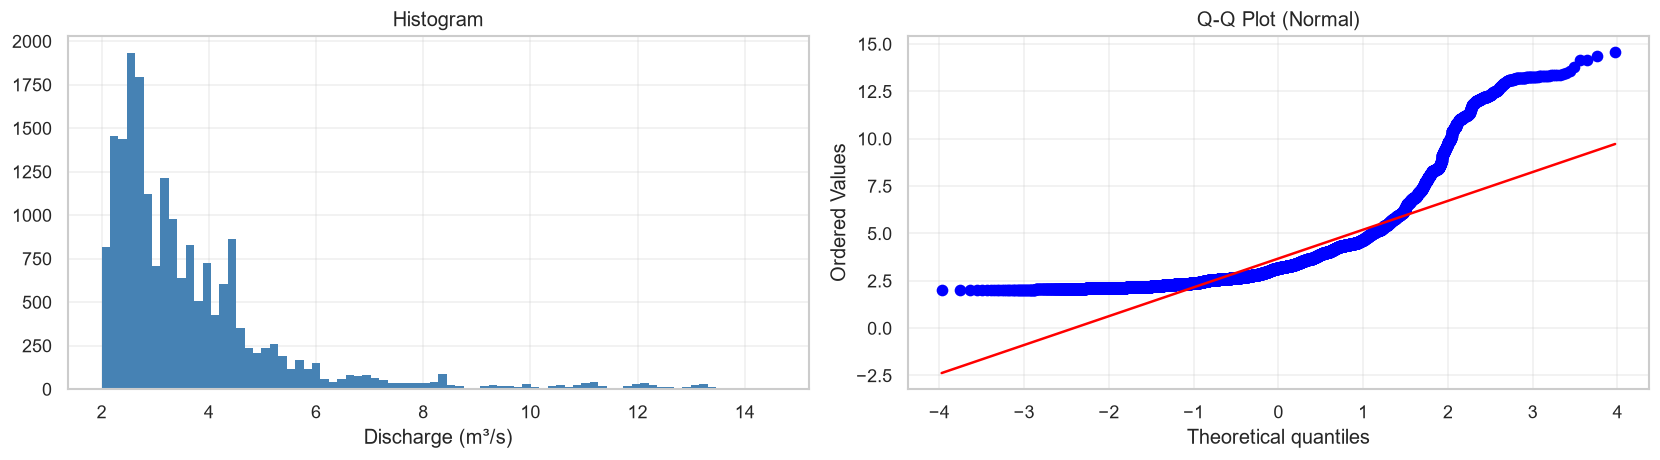

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

series.dropna().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Histogram")
axes[0].set_xlabel(SERIES_LABEL)

stats.probplot(series.dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normal)")

plt.tight_layout()
plt.show()

## 7 — Outlier Detection

IQR outliers (±3×IQR)  : 518  (2.66 %)
Z-score outliers (|z|>4): 342  (1.76 %)


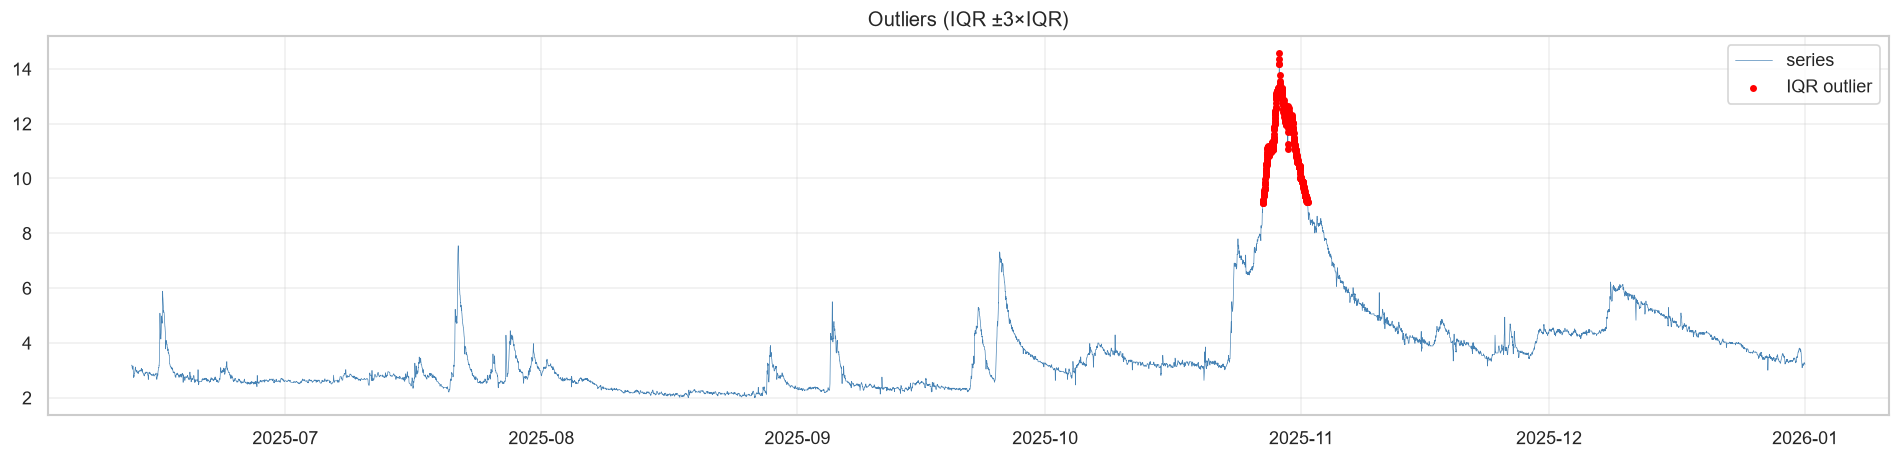

In [15]:
clean = series.dropna()

# IQR method
Q1, Q3 = clean.quantile(0.25), clean.quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = clean[(clean < Q1 - 3*IQR) | (clean > Q3 + 3*IQR)]

# Z-score method
z_scores = np.abs(stats.zscore(clean))
z_outliers = clean[z_scores > 4]

print(f"IQR outliers (±3×IQR)  : {len(iqr_outliers):,}  ({100*len(iqr_outliers)/len(clean):.2f} %)")
print(f"Z-score outliers (|z|>4): {len(z_outliers):,}  ({100*len(z_outliers)/len(clean):.2f} %)")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(clean.index, clean.values, lw=0.4, color="steelblue", label="series")
ax.scatter(iqr_outliers.index, iqr_outliers.values, color="red", s=10, zorder=5, label="IQR outlier")
ax.set_title("Outliers (IQR ±3×IQR)")
ax.legend()
plt.tight_layout()
plt.show()

## 8 — Seasonality Profiles

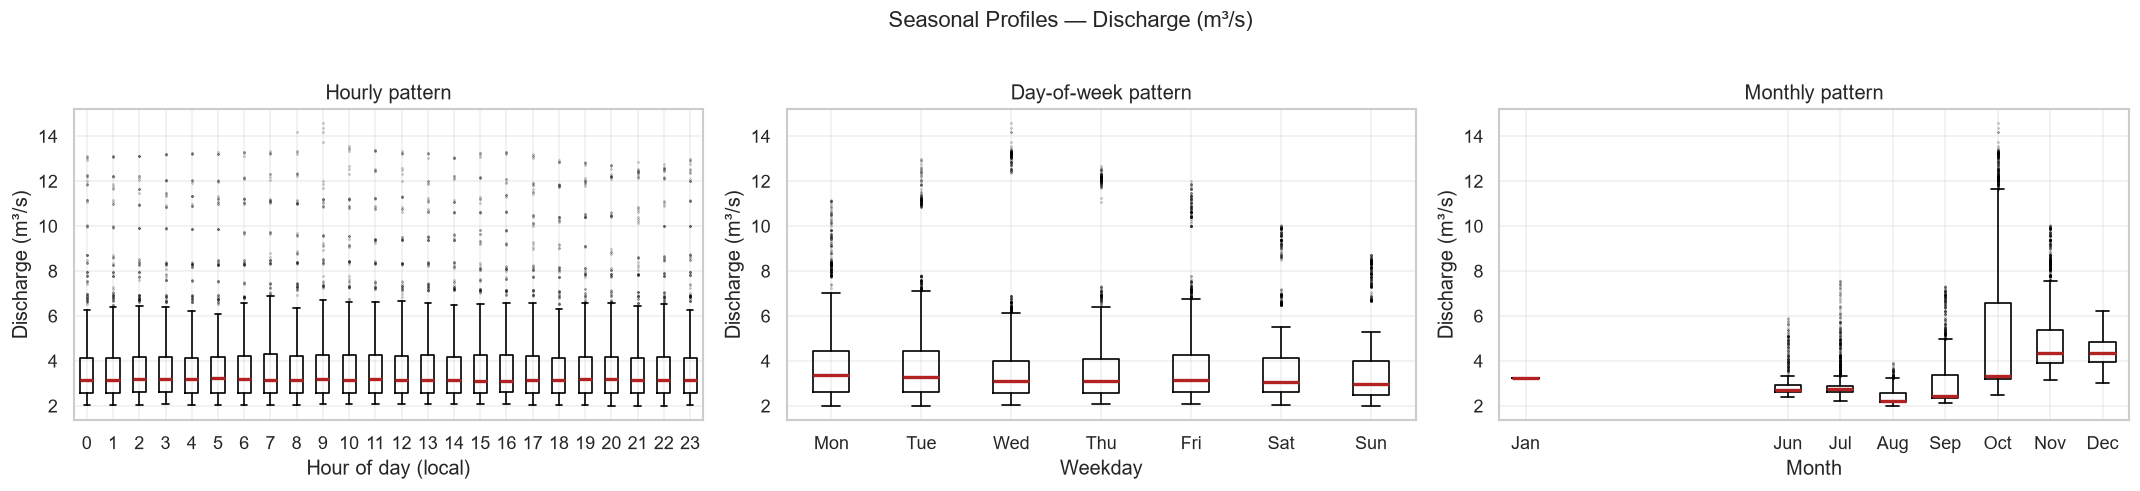

In [16]:
s = series.dropna().copy()
s_local = s.tz_convert("Europe/Berlin")  # shift to local time for seasonal plots

by_hour    = s_local.groupby(s_local.index.hour)
by_weekday = s_local.groupby(s_local.index.dayofweek)
by_month   = s_local.groupby(s_local.index.month)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def box_plot(grouped, ax, xlabel, xticks=None):
    keys = sorted(grouped.groups.keys())
    data = [grouped.get_group(k).values for k in keys]
    ax.boxplot(data, positions=keys, widths=0.5,
               medianprops=dict(color="firebrick", lw=2),
               flierprops=dict(marker=".", markersize=1, alpha=0.3))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(SERIES_LABEL)
    if xticks:
        ax.set_xticks(list(range(len(xticks))))
        ax.set_xticklabels(xticks, rotation=45)

box_plot(by_hour,    axes[0], "Hour of day (local)")
axes[0].set_title("Hourly pattern")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
keys = sorted(by_weekday.groups.keys())
data = [by_weekday.get_group(k).values for k in keys]
axes[1].boxplot(data, positions=keys, widths=0.4,
                medianprops=dict(color="firebrick", lw=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.3))
axes[1].set_xticks(keys)
axes[1].set_xticklabels(day_labels)
axes[1].set_title("Day-of-week pattern")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel(SERIES_LABEL)

import calendar
month_labels = [calendar.month_abbr[m] for m in sorted(by_month.groups.keys())]
keys = sorted(by_month.groups.keys())
data = [by_month.get_group(k).values for k in keys]
axes[2].boxplot(data, positions=keys, widths=0.5,
                medianprops=dict(color="firebrick", lw=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.3))
axes[2].set_xticks(keys)
axes[2].set_xticklabels(month_labels)
axes[2].set_title("Monthly pattern")
axes[2].set_xlabel("Month")
axes[2].set_ylabel(SERIES_LABEL)

plt.suptitle(f"Seasonal Profiles — {SERIES_LABEL}", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 9 — Heatmaps (Hour × Day, Hour × Month)

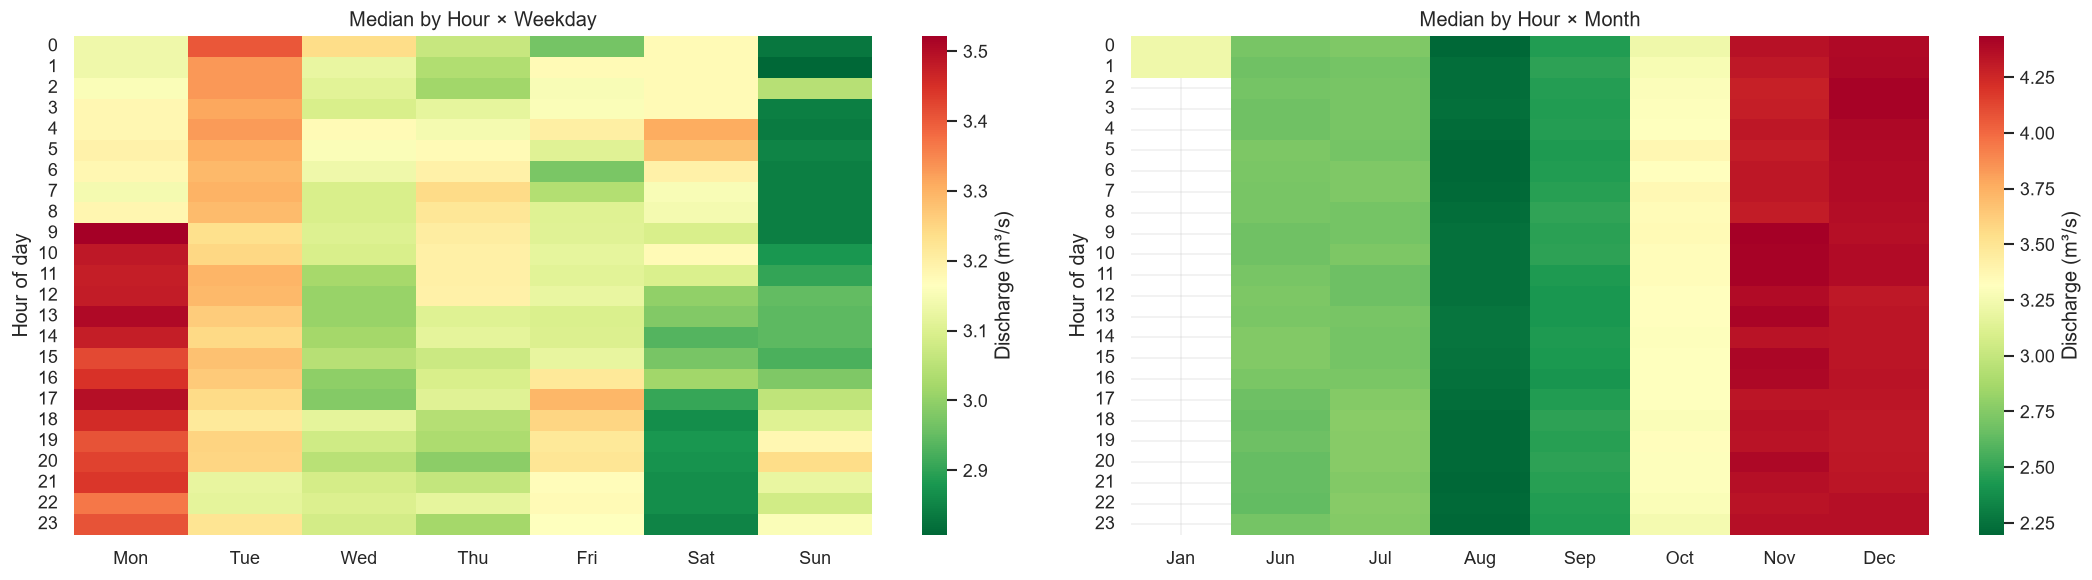

In [17]:
df_heat = s_local.to_frame(name="value")
df_heat["hour"]    = df_heat.index.hour
df_heat["weekday"] = df_heat.index.dayofweek
df_heat["month"]   = df_heat.index.month

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

pivot1 = df_heat.pivot_table(index="hour", columns="weekday", values="value", aggfunc="median")
pivot1.columns = day_labels
sns.heatmap(pivot1, ax=axes[0], cmap="RdYlGn_r", cbar_kws={"label": SERIES_LABEL})
axes[0].set_title("Median by Hour × Weekday")
axes[0].set_ylabel("Hour of day")

pivot2 = df_heat.pivot_table(index="hour", columns="month", values="value", aggfunc="median")
pivot2.columns = [calendar.month_abbr[m] for m in pivot2.columns]
sns.heatmap(pivot2, ax=axes[1], cmap="RdYlGn_r", cbar_kws={"label": SERIES_LABEL})
axes[1].set_title("Median by Hour × Month")
axes[1].set_ylabel("Hour of day")

plt.tight_layout()
plt.show()

## 10 — Stationarity Tests

In [18]:
# Work on a downsampled version to keep tests tractable
s_test = series.dropna().resample("1h").mean().dropna()

# --- ADF ---
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s_test, autolag="AIC")
print("=== Augmented Dickey-Fuller Test ===")
print(f"  ADF statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.4f}")
for k, v in adf_crit.items():
    print(f"  Critical ({k})  : {v:.4f}")
print(f"  → {'STATIONARY' if adf_p < 0.05 else 'NON-STATIONARY'} at 5 % level")

# --- KPSS ---
kpss_stat, kpss_p, _, kpss_crit = kpss(s_test, regression="c", nlags="auto")
print("\n=== KPSS Test ===")
print(f"  KPSS statistic: {kpss_stat:.4f}")
print(f"  p-value       : {kpss_p:.4f}")
for k, v in kpss_crit.items():
    print(f"  Critical ({k}) : {v:.4f}")
print(f"  → {'NON-STATIONARY' if kpss_p < 0.05 else 'STATIONARY'} at 5 % level")

=== Augmented Dickey-Fuller Test ===
  ADF statistic : -2.7830
  p-value       : 0.0607
  Critical (1%)  : -3.4317
  Critical (5%)  : -2.8621
  Critical (10%)  : -2.5671
  → NON-STATIONARY at 5 % level

=== KPSS Test ===
  KPSS statistic: 3.4165
  p-value       : 0.0100
  Critical (10%) : 0.3470
  Critical (5%) : 0.4630
  Critical (2.5%) : 0.5740
  Critical (1%) : 0.7390
  → NON-STATIONARY at 5 % level


## 11 — ACF / PACF

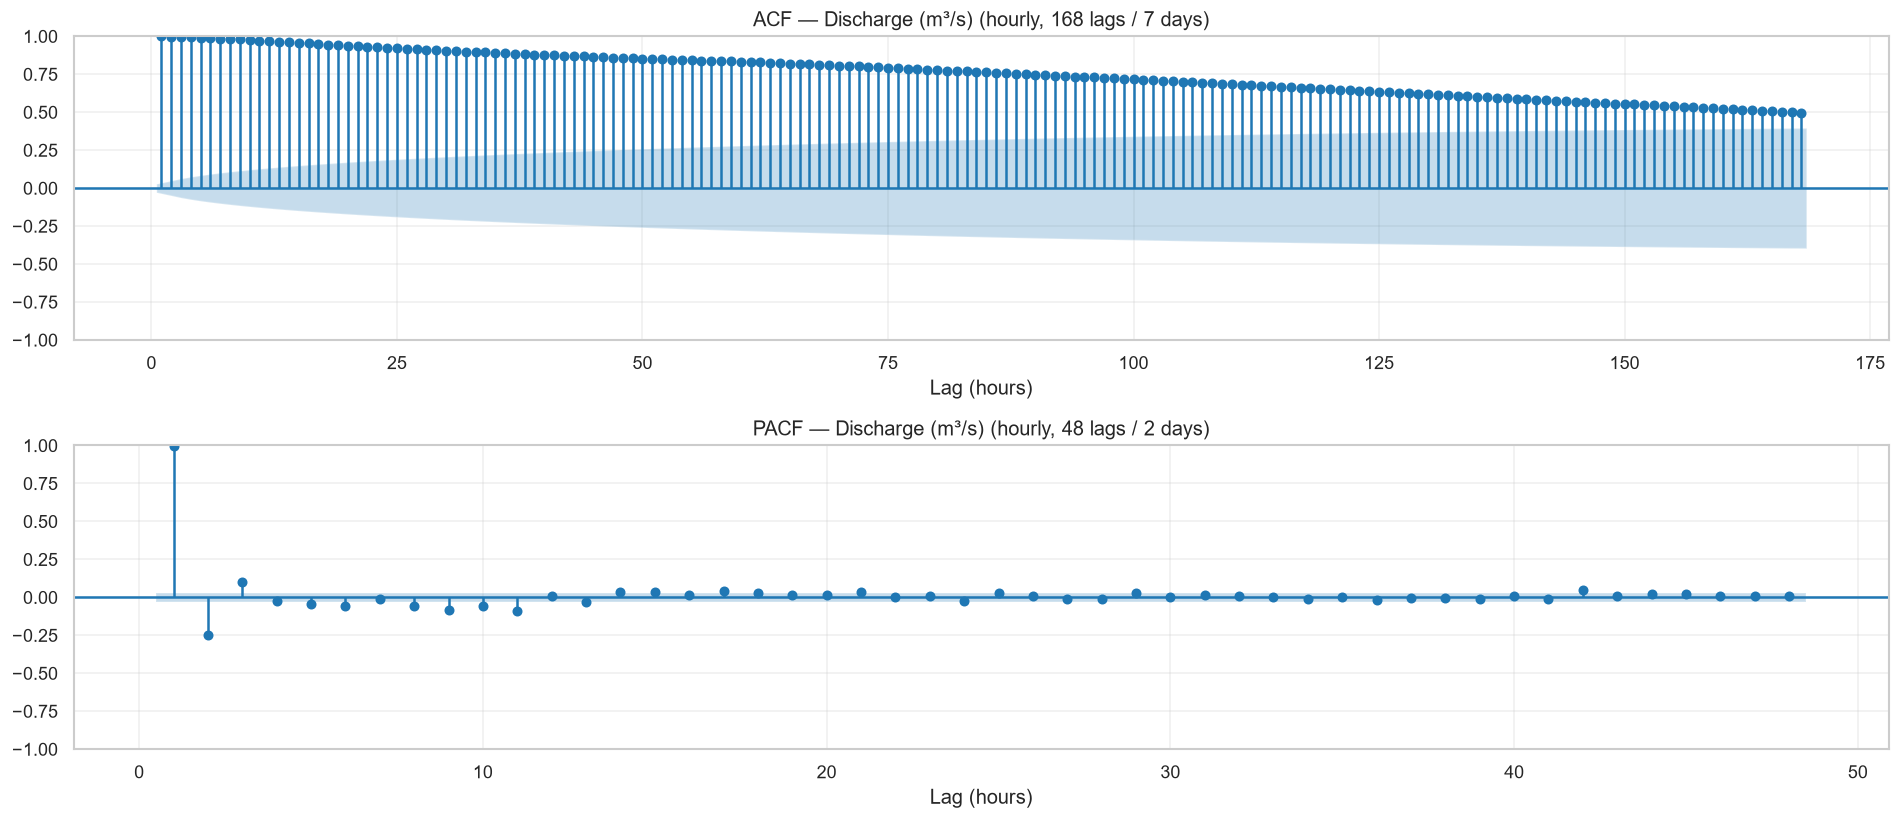

In [19]:
# Use hourly-resampled series; show 7 days of lags
s_hourly = series.dropna().resample("1h").mean().dropna()
n_lags = min(168, len(s_hourly) // 3)  # 7 days of hourly lags

fig, axes = plt.subplots(2, 1, figsize=(16, 7))
plot_acf( s_hourly, lags=n_lags, ax=axes[0], alpha=0.05, zero=False)
axes[0].set_title(f"ACF — {SERIES_LABEL} (hourly, {n_lags} lags / 7 days)")
axes[0].set_xlabel("Lag (hours)")

plot_pacf(s_hourly, lags=min(48, n_lags), ax=axes[1], alpha=0.05, zero=False, method="ywm")
axes[1].set_title(f"PACF — {SERIES_LABEL} (hourly, 48 lags / 2 days)")
axes[1].set_xlabel("Lag (hours)")

plt.tight_layout()
plt.show()

## 12 — STL Decomposition

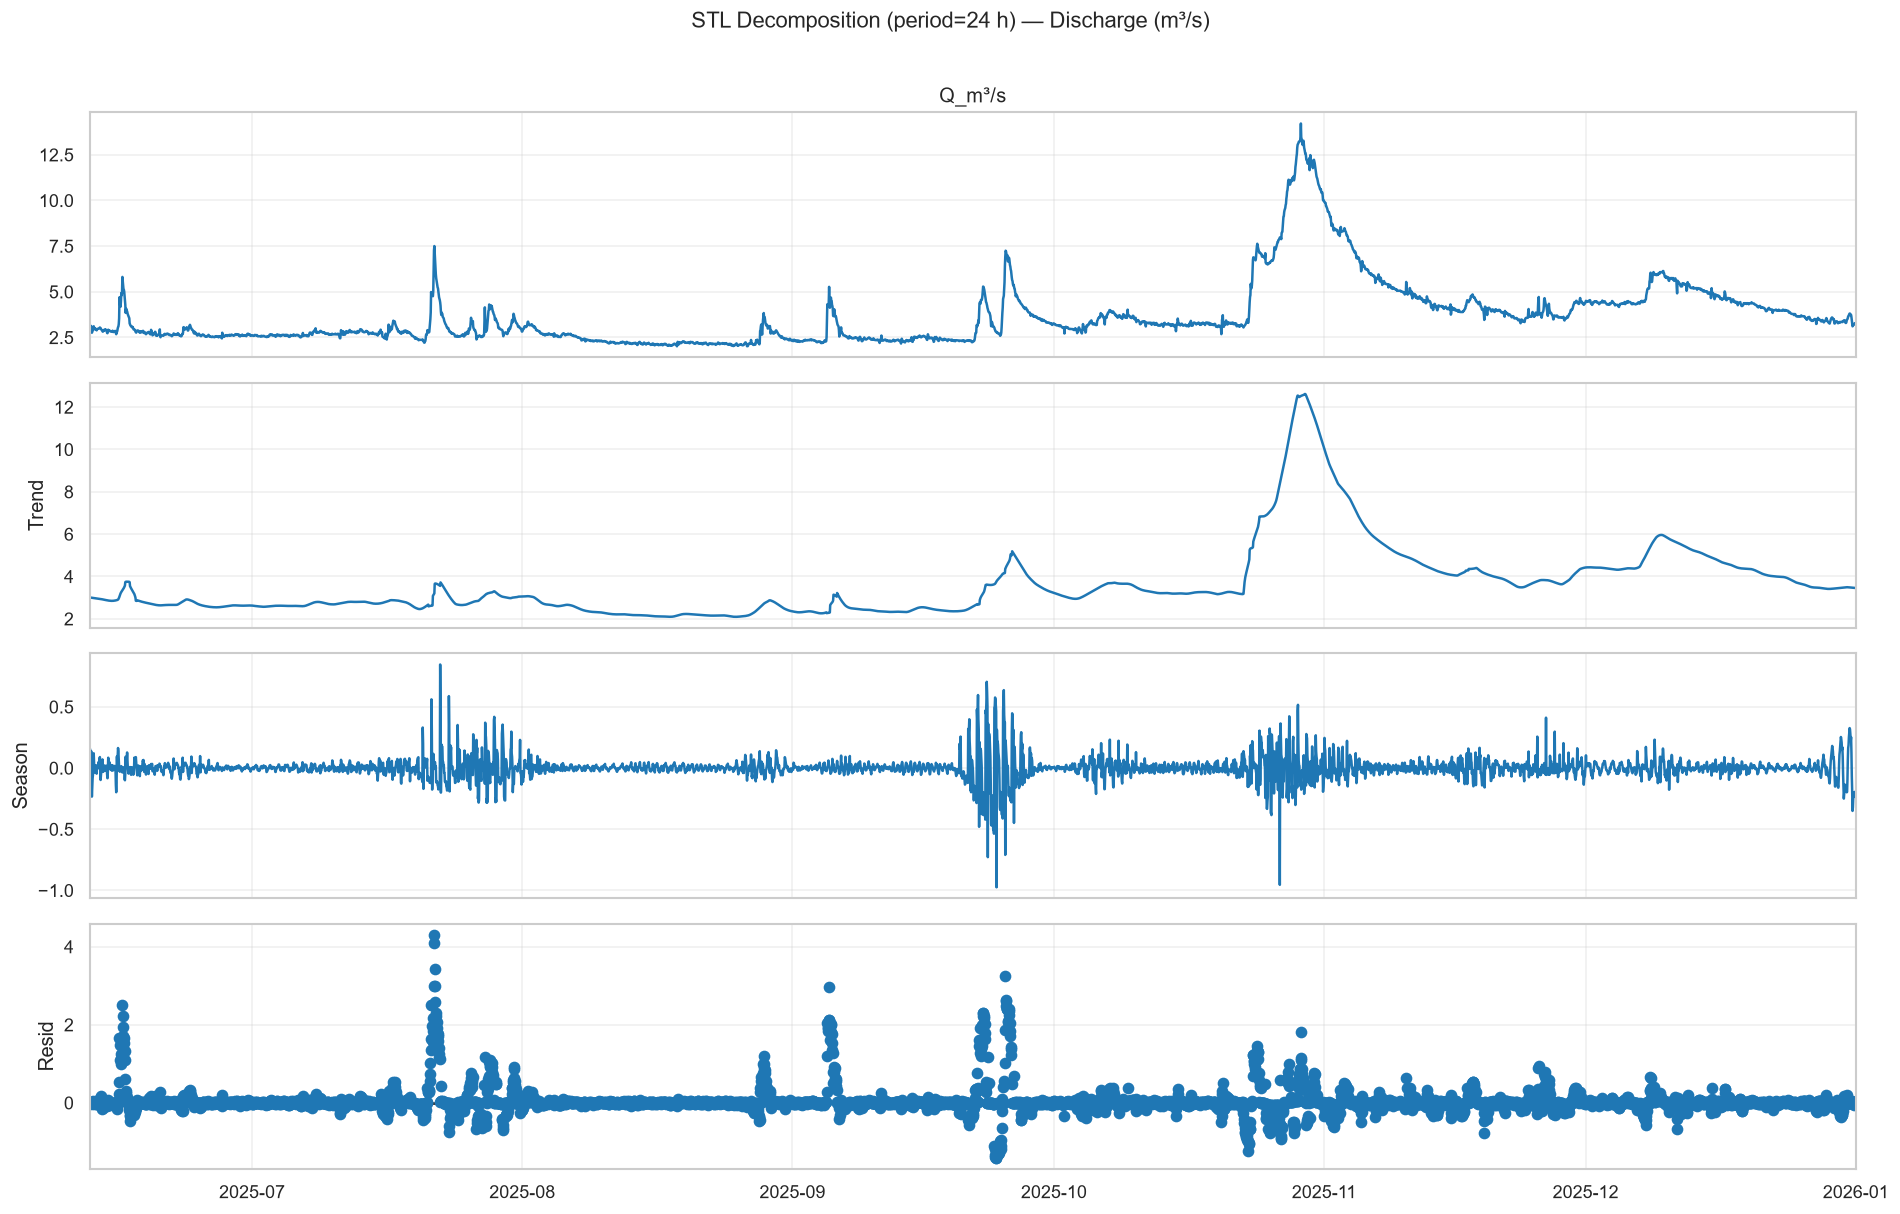

Variance explained:
  Seasonal  : 0.2 %
  Trend     : 95.6 %
  Residual  : 3.8 %


In [20]:
# Hourly series — use 24-hour seasonal period
s_stl = series.dropna().resample("1h").mean().interpolate(limit=6)

stl = STL(s_stl, period=24, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 10)
fig.suptitle(f"STL Decomposition (period=24 h) — {SERIES_LABEL}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Variance explained
total_var    = s_stl.var()
seasonal_var = result.seasonal.var()
trend_var    = result.trend.var()
resid_var    = result.resid.var()

print(f"Variance explained:")
print(f"  Seasonal  : {100*seasonal_var/total_var:.1f} %")
print(f"  Trend     : {100*trend_var/total_var:.1f} %")
print(f"  Residual  : {100*resid_var/total_var:.1f} %")

## 13 — Weekly Decomposition (STL, period=168 h)

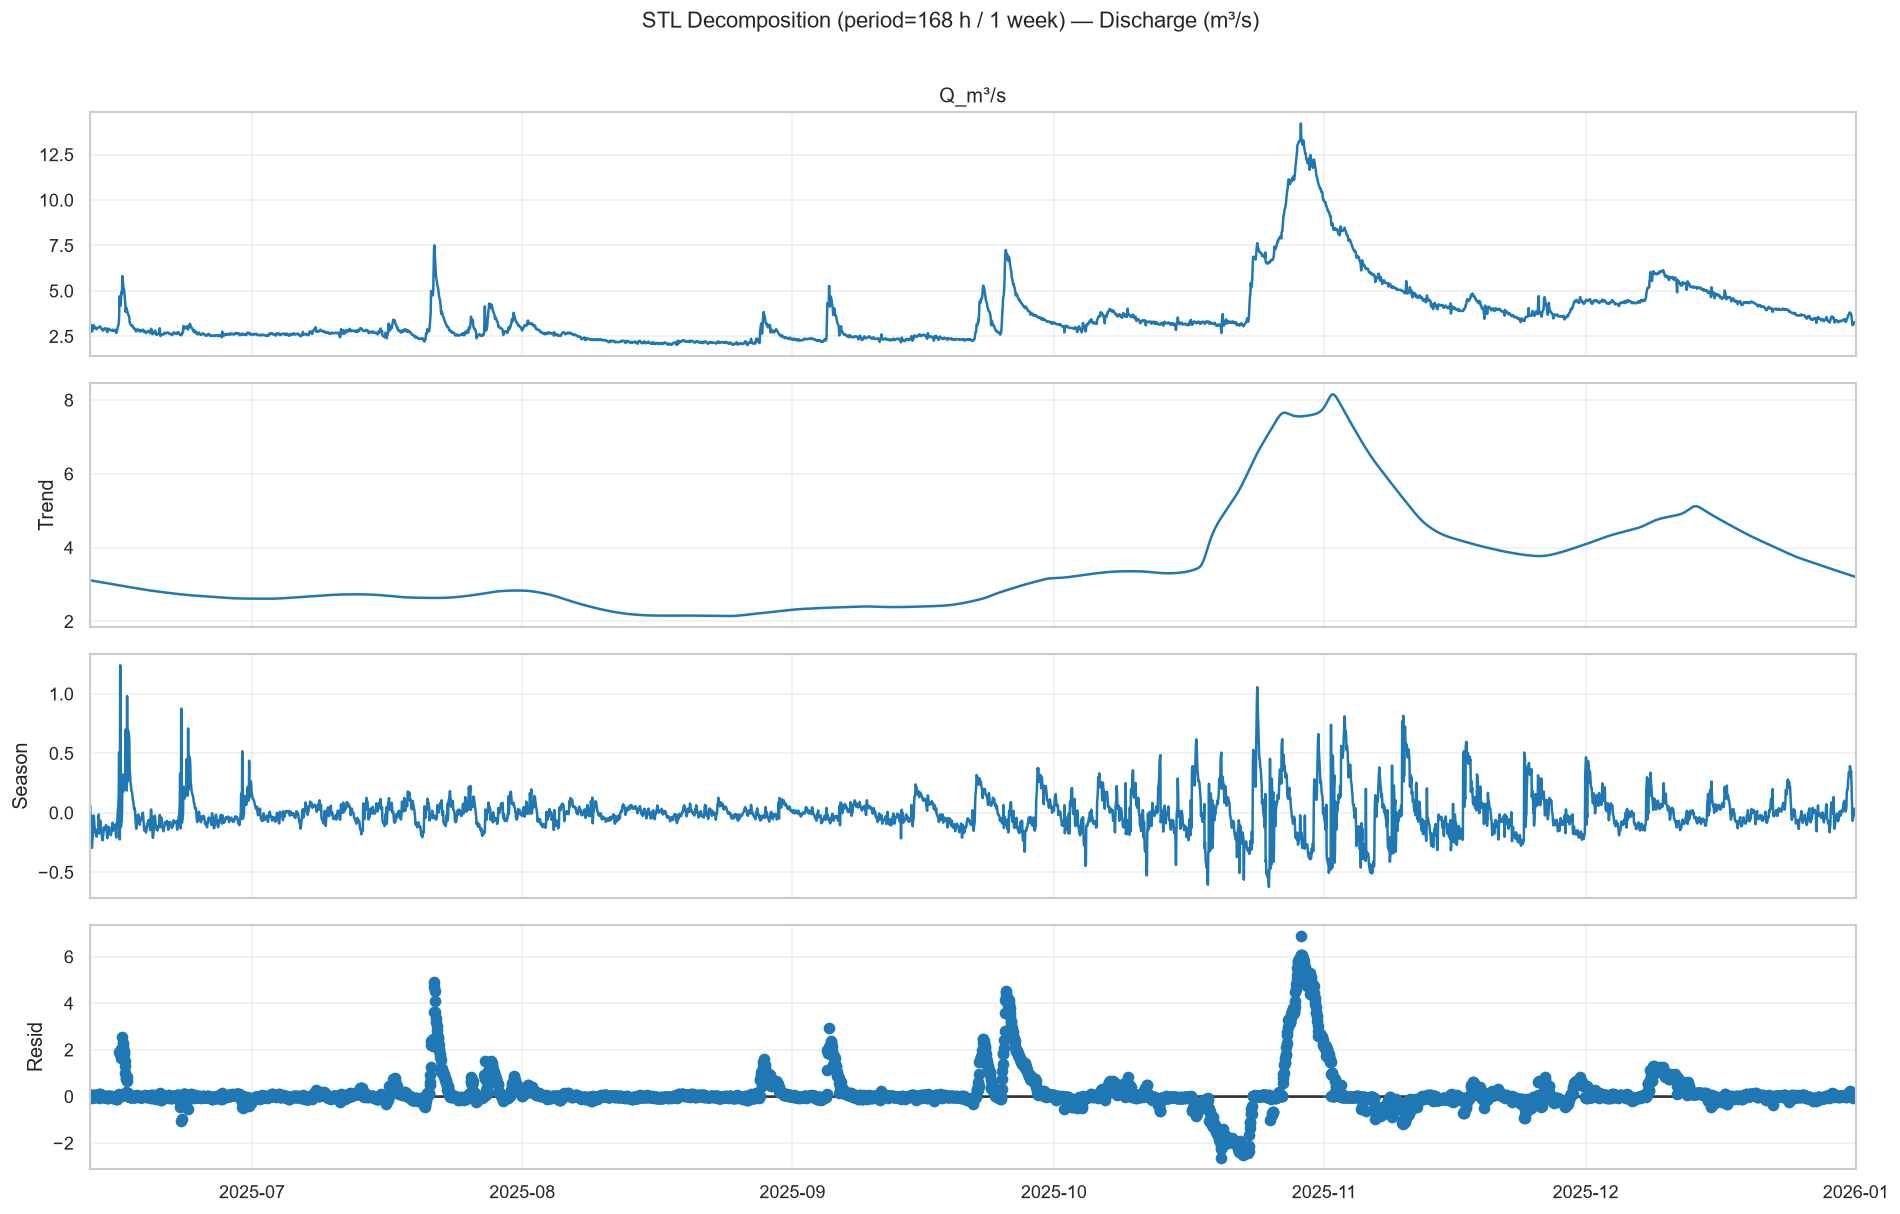

Variance explained (weekly STL):
  Seasonal  : 0.8 %
  Trend     : 60.6 %
  Residual  : 23.6 %


In [21]:
stl_week = STL(s_stl, period=168, robust=True)
result_week = stl_week.fit()

fig = result_week.plot()
fig.set_size_inches(16, 10)
fig.suptitle(f"STL Decomposition (period=168 h / 1 week) — {SERIES_LABEL}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

total_var    = s_stl.var()
seasonal_var = result_week.seasonal.var()
trend_var    = result_week.trend.var()
resid_var    = result_week.resid.var()
print(f"Variance explained (weekly STL):")
print(f"  Seasonal  : {100*seasonal_var/total_var:.1f} %")
print(f"  Trend     : {100*trend_var/total_var:.1f} %")
print(f"  Residual  : {100*resid_var/total_var:.1f} %")

## 14 — Year-over-Year Comparison

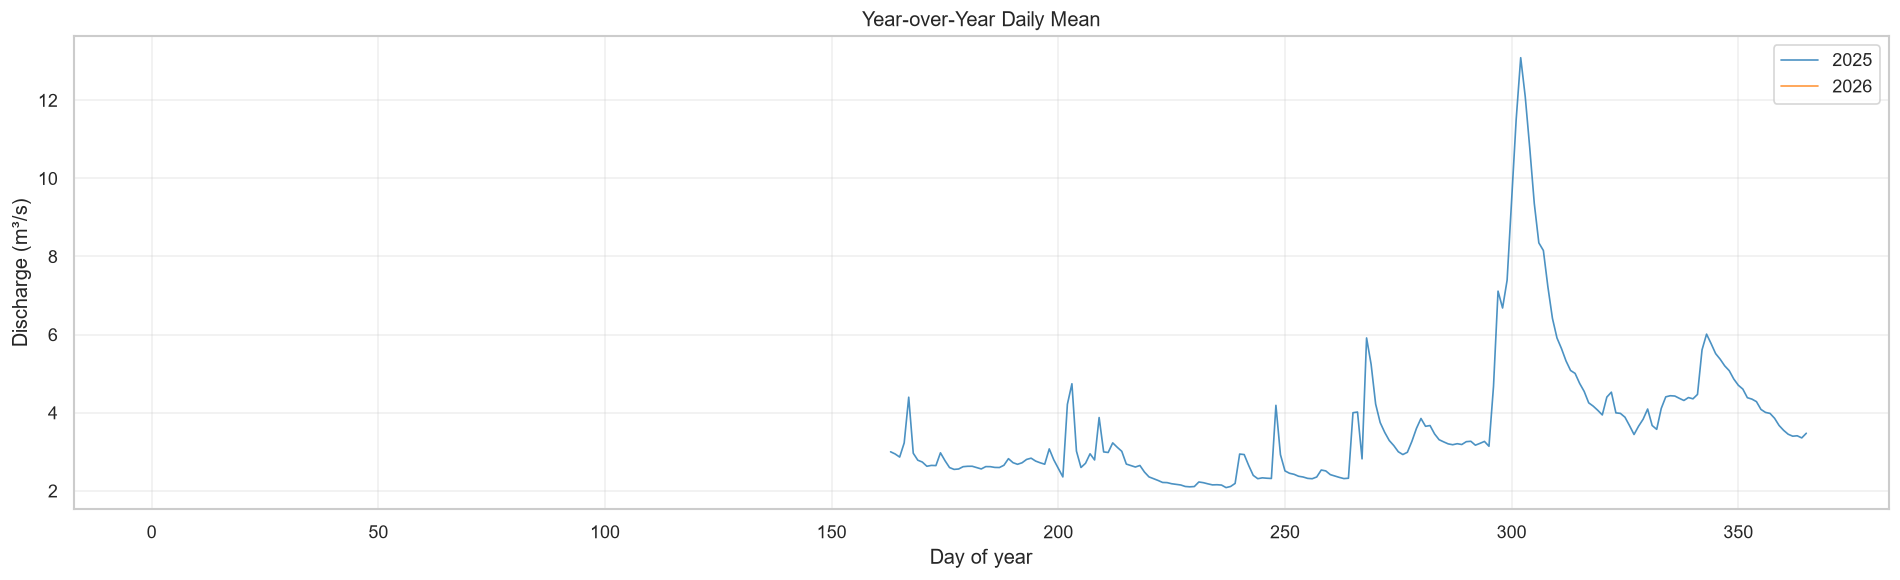

In [22]:
s_daily = series.dropna().resample("1D").mean()
years   = sorted(s_daily.index.year.unique())

if len(years) > 1:
    fig, ax = plt.subplots(figsize=(16, 5))
    cmap = plt.get_cmap("tab10")
    for i, yr in enumerate(years):
        yr_data = s_daily[s_daily.index.year == yr].copy()
        yr_data.index = yr_data.index.dayofyear
        ax.plot(yr_data.index, yr_data.values, lw=1, label=str(yr), color=cmap(i), alpha=0.8)
    ax.set_xlabel("Day of year")
    ax.set_ylabel(SERIES_LABEL)
    ax.set_title("Year-over-Year Daily Mean")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Only one year of data — YoY plot skipped.")

## 15 — Summary

In [23]:
print("=" * 60)
print(f"SUMMARY — {SERIES_LABEL}")
print("=" * 60)
print(f"Time range      : {series.index.min()} → {series.index.max()}")
print(f"Observations    : {len(series):,}")
print(f"Missing values  : {series.isna().sum():,}  ({100*series.isna().mean():.2f} %)")
print(f"Mean            : {series.mean():.3f}")
print(f"Std             : {series.std():.3f}")
print(f"Min / Max       : {series.min():.3f} / {series.max():.3f}")
print(f"IQR outliers    : {len(iqr_outliers):,}  ({100*len(iqr_outliers)/series.dropna().__len__():.2f} %)")
print(f"ADF stationarity: {'YES' if adf_p < 0.05 else 'NO '} (p={adf_p:.4f})")
print(f"KPSS stationary : {'YES' if kpss_p >= 0.05 else 'NO '} (p={kpss_p:.4f})")
print("=" * 60)

SUMMARY — Discharge (m³/s)
Time range      : 2025-06-12 09:00:00+00:00 → 2026-01-01 00:00:00+00:00
Observations    : 19,453
Missing values  : 0  (0.00 %)
Mean            : 3.674
Std             : 1.786
Min / Max       : 1.998 / 14.564
IQR outliers    : 518  (2.66 %)
ADF stationarity: NO  (p=0.0607)
KPSS stationary : NO  (p=0.0100)
